In [3]:
import numpy as np
import matplotlib.pyplot as plt 
from scipy.io import loadmat,savemat
import seaborn as sns

def patternimage(full_size_pattern):
    image = (full_size_pattern-full_size_pattern.min()).reshape(28,28)
    return image

In [ ]:
# downlaod data from https://drive.google.com/drive/folders/1aDvzXkTN8XeibHVKSMj-bgmHThXzBGho?lfhs=2 
# a folder named MNIST.zip
import mcpca

# 0,2 /1,2 

In [ ]:
# # superimpose digit images on cloud and grass images

# # background (50% grass, 50% cloud), foreground 1 (80% grass, 20% cloud), foreground 2 (20% grass, 80% cloud)

# path for image folders
## replace it with your own path
path = '/Users/kexinwang/Documents/harvard/research/contrastive_ICA/python'

import keras
from keras.datasets import mnist
np.random.seed(0)
(X_train, y_train), (X_test, y_test) = mnist.load_data()
index_0=np.random.choice(list(np.where(y_train==0)[0]),10000,replace = True)
index_1=np.random.choice(list(np.where(y_train == 1)[0]),10000, replace = True)
index_2=np.random.choice(list(np.where(y_train == 2)[0]),20000, replace = True)
strength = np.random.uniform(0,1,(4,10000))
foreground_0_2=np.zeros(shape = (10000,28,28))
foreground_1_2=np.zeros(shape = (10000,28,28))


for i in range(10000):
    foreground_0_2[i,:]=(X_train[index_0[i]]*strength[0,i]+X_train[index_2[i]]*strength[1,i])/255
    foreground_1_2[i,:]=(X_train[index_1[i]]*strength[2,i]+X_train[index_2[i+10000]]*strength[3,i])/255
   

foreground_0_ = np.zeros(shape = (10000,28,28))
foreground_2_1 = np.zeros(shape = (10000,28,28))
foreground_1_ = np.zeros(shape = (10000,28,28))
foreground_2_2 = np.zeros(shape = (10000,28,28))
for i in range(10000):
    foreground_0_[i,:] = X_train[index_0[i]]*strength[0,i]
    foreground_2_1[i,:] = X_train[index_2[i]]*strength[1,i]
    foreground_1_[i,:] = X_train[index_1[i]]*strength[2,i]
    foreground_2_2[i,:] = X_train[index_2[i]]*strength[3,i]

average_0 = np.mean(foreground_0_,axis=0)/255
average_2_1 = np.mean(foreground_2_1,axis=0)/255
average_1 = np.mean(foreground_1_,axis=0)/255
average_2_2 = np.mean(foreground_2_2,axis=0)/255


from PIL import Image
from resizeimage import resizeimage
import os

grass_IMAGE_PATH = path+'/n12102133/' #Replace with your own path to downloaded images
cloud_IMAGE_PATH = path+'/n09247410/' #Replace with your own path to downloaded images
        
grass_images = list() #dictionary of pictures indexed by the pic # and each value is 100x100 image
num=0
for filename in os.listdir(grass_IMAGE_PATH):
    num+=1
    if filename.endswith(".JPEG") or filename.endswith(".JPG") or filename.endswith(".jpg"):
        try:
            im = Image.open(os.path.join(grass_IMAGE_PATH,filename))
            im = im.convert(mode="L") #convert to grayscale

            im = resizeimage.resize_crop(im,[100,100]) #resize and crop each picture to be 100px by 100px
            grass_images.append(np.reshape(im, [10000])) 
        except Exception as e:
            pass #print(e)
            
grass_images=np.asarray(grass_images,dtype=float)
grass_images/=255 #rescale to be 0-1
print("Array of grass images:",grass_images.shape)


cloud_images = list() #dictionary of pictures indexed by the pic # and each value is 100x100 image
num=0
for filename in os.listdir(cloud_IMAGE_PATH):
    num+=1
    if filename.endswith(".JPEG") or filename.endswith(".JPG") or filename.endswith(".jpg"):
        try:
            im = Image.open(os.path.join(cloud_IMAGE_PATH,filename))
            im = im.convert(mode="L") #convert to grayscale

            im = resizeimage.resize_crop(im,[100,100]) #resize and crop each picture to be 100px by 100px
            cloud_images.append(np.reshape(im, [10000])) 
        except Exception as e:
            pass #print(e)
    
cloud_images=np.asarray(cloud_images,dtype=float)
cloud_images/=255 #rescale to be 0-1
print("Array of cloud images:",cloud_images.shape)

# Corrupt the MNIST digits with the grass and cloud images 
from tqdm import tqdm

np.random.seed(0)  # for reproducibility

grass_rand_indices = np.random.permutation(
    grass_images.shape[0]
)  # just shuffles the indices
grass_split = int(len(grass_rand_indices) / 2)
target_grass_indices = grass_rand_indices[
    0:grass_split
]  # choose the first half of images to be superimposed on target
background_grass_indices = grass_rand_indices[
    grass_split:
]  # choose the second half of images to be background dataset



cloud_rand_indices = np.random.permutation(
    cloud_images.shape[0]
)  # just shuffles the indices
cloud_split = int(len(cloud_rand_indices) / 2)
target_cloud_indices = cloud_rand_indices[
    0:cloud_split
]  # choose the first half of images to be superimposed on target
background_cloud_indices = cloud_rand_indices[
    cloud_split:
]  # choose the second half of images to be background dataset

background = np.zeros((foreground_0_2.shape[0],28**2))


permuted_index = np.random.permutation(10000)
# np.random.seed(1)
# permuted_index_2=np.random.permutation(10000)
np.random.seed(0)
print("Corrupting MNIST with grass and cloud...")

grass_cloud_foreground_0_2 = np.zeros((foreground_0_.shape[0],28**2))
grass_cloud_foreground_1_2 = np.zeros((foreground_0_.shape[0],28**2))

# generate backgroud
for i in range(background.shape[0]//2):
    idx = np.random.choice(background_grass_indices) # randomly pick a image 
    loc = np.random.randint(70,size=(2)) # randomly pick a region in the image
    background_patch = np.reshape(np.reshape(grass_images[idx,:],[100,100])[loc[0]:loc[0]+28,:][:,loc[1]:loc[1]+28] ,[1,784])    
    background[permuted_index[i]] = background_patch

    idx = np.random.choice(background_cloud_indices) # randomly pick a image
    loc = np.random.randint(70,size=(2)) # randomly pick a region in the image
    background_patch = np.reshape(np.reshape(cloud_images[idx,:],[100,100])[loc[0]:loc[0]+28,:][:,loc[1]:loc[1]+28] ,[1,784])
    background[permuted_index[i+background.shape[0]//2]] = background_patch

# generate background for foreground_0_2
for i in range(int(foreground_0_2.shape[0]/10*8)):
    idx = np.random.choice(target_grass_indices) # randomly pick a image 
    loc = np.random.randint(70,size=(2)) # randomly pick a region in the image
    superimposed_patch = np.reshape(np.reshape(grass_images[idx,:],[100,100])[loc[0]:loc[0]+28,:][:,loc[1]:loc[1]+28] ,[1,784]) 
    grass_cloud_foreground_0_2[i]=superimposed_patch

for i in range(int(foreground_0_2.shape[0]/10*8),foreground_0_2.shape[0]):
    idx = np.random.choice(target_cloud_indices) # randomly pick a image
    loc = np.random.randint(70,size=(2)) # randomly pick a region in the image
    superimposed_patch = np.reshape(np.reshape(cloud_images[idx,:],[100,100])[loc[0]:loc[0]+28,:][:,loc[1]:loc[1]+28] ,[1,784])
    grass_cloud_foreground_0_2[i]=superimposed_patch

# superimpose digits
for i in range(10000):
    foregroundreshaped=foreground_0_2[i].reshape(1,-1)
    grass_cloud_foreground_0_2[i] = foregroundreshaped+ grass_cloud_foreground_0_2[permuted_index[i]]


# generate background for foreground_1_2
for i in range(int(foreground_1_2.shape[0]/10*8)):
    idx = np.random.choice(target_cloud_indices) # randomly pick a image 
    loc = np.random.randint(70,size=(2)) # randomly pick a region in the image
    superimposed_patch = np.reshape(np.reshape(cloud_images[idx,:],[100,100])[loc[0]:loc[0]+28,:][:,loc[1]:loc[1]+28] ,[1,784]) 
    grass_cloud_foreground_1_2[i]=superimposed_patch

for i in range(int(foreground_1_2.shape[0]/10*8),foreground_1_2.shape[0]):
    idx = np.random.choice(target_grass_indices) # randomly pick a image
    loc = np.random.randint(70,size=(2)) # randomly pick a region in the image
    superimposed_patch = np.reshape(np.reshape(grass_images[idx,:],[100,100])[loc[0]:loc[0]+28,:][:,loc[1]:loc[1]+28] ,[1,784])
    grass_cloud_foreground_1_2[i]=superimposed_patch
# superimpose digits
for i in range(10000):
    foregroundreshaped=foreground_1_2[i].reshape(1,-1)
    grass_cloud_foreground_1_2[i] = foregroundreshaped+ grass_cloud_foreground_1_2[permuted_index[i]]


np.save("background.npy", background)
np.save("foreground_0_2.npy", grass_cloud_foreground_0_2)
np.save("foreground_1_2.npy", grass_cloud_foreground_1_2)

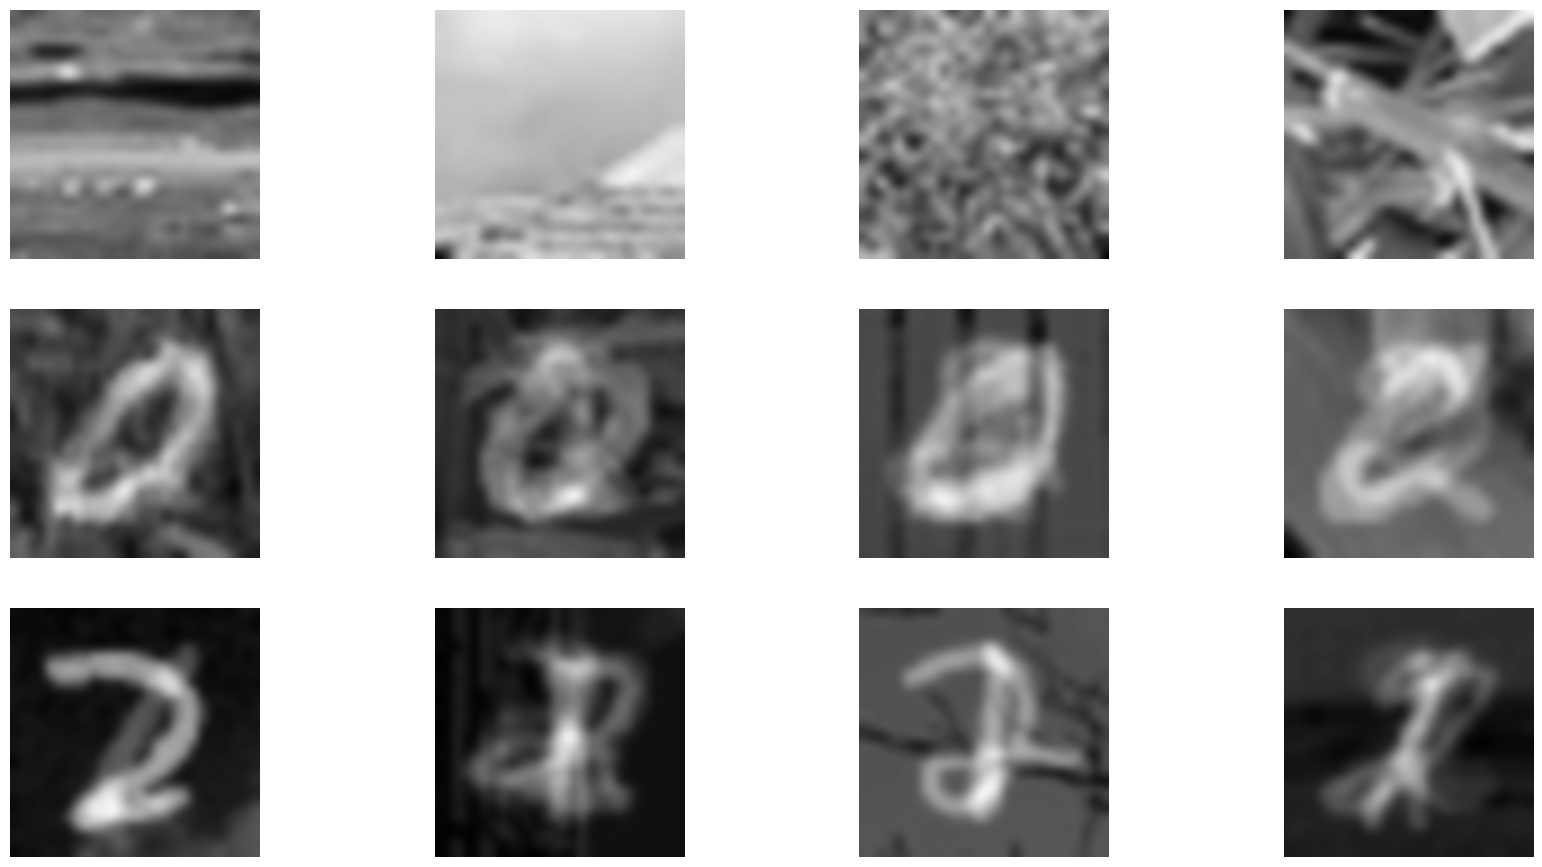

In [4]:
# visualize the images
background = np.load("background.npy")
foreground_0_2 = np.load("foreground_0_2.npy")
foreground_1_2 = np.load("foreground_1_2.npy")
n_show = 4

plt.figure(figsize=[21, 11])
idx = np.random.randint(10000, size=n_show)
for i in range(n_show):
    plt.subplot(3, n_show, i + 1)
    plt.imshow(
        np.reshape(background[idx[i], :], [28, 28]), cmap="gray", interpolation="bicubic"
    )
    plt.axis("off")


for i in range(n_show):
    plt.subplot(3, n_show, n_show + i + 1)
    idx = np.random.randint(10000)
    plt.imshow(
        np.reshape(foreground_0_2[idx, :], [28, 28]), cmap="gray", interpolation="bicubic"
    )
    plt.axis("off")

for i in range(n_show):
    plt.subplot(3, n_show, 2*n_show + i + 1)
    idx = np.random.randint(10000)
    plt.imshow(
        np.reshape(foreground_1_2[idx, :], [28, 28]), cmap="gray", interpolation="bicubic"
    )
    plt.axis("off")

plt.show()

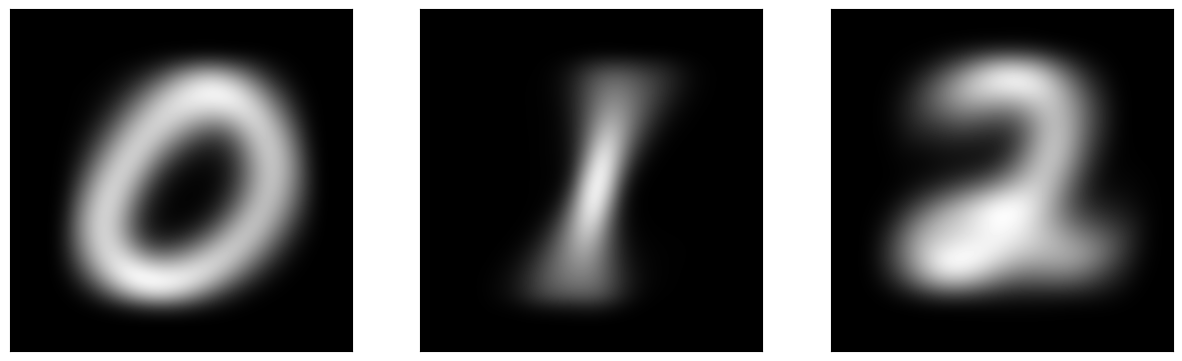

In [13]:
# avergae images
import keras
from keras.datasets import mnist
np.random.seed(0)
(X_train, y_train), (X_test, y_test) = mnist.load_data()
index_0=np.random.choice(list(np.where(y_train==0)[0]),10000,replace = True)
index_1=np.random.choice(list(np.where(y_train == 1)[0]),10000, replace = True)
index_2=np.random.choice(list(np.where(y_train == 2)[0]),20000, replace = True)
strength = np.random.uniform(0,1,(4,10000))
foreground_0_2=np.zeros(shape = (10000,28,28))
foreground_1_2=np.zeros(shape = (10000,28,28))


for i in range(10000):
    foreground_0_2[i,:]=(X_train[index_0[i]]*strength[0,i]+X_train[index_2[i]]*strength[1,i])/255
    foreground_1_2[i,:]=(X_train[index_1[i]]*strength[2,i]+X_train[index_2[i+10000]]*strength[3,i])/255
   

foreground_0_ = np.zeros(shape = (10000,28,28))
foreground_2_1 = np.zeros(shape = (10000,28,28))
foreground_1_ = np.zeros(shape = (10000,28,28))
foreground_2_2 = np.zeros(shape = (10000,28,28))
for i in range(10000):
    foreground_0_[i,:] = X_train[index_0[i]]*strength[0,i]
    foreground_2_1[i,:] = X_train[index_2[i]]*strength[1,i]
    foreground_1_[i,:] = X_train[index_1[i]]*strength[2,i]
    foreground_2_2[i,:] = X_train[index_2[i]]*strength[3,i]

average_0 = np.mean(foreground_0_,axis=0)/255
average_2_1 = np.mean(foreground_2_1,axis=0)/255
average_1 = np.mean(foreground_1_,axis=0)/255
average_2_2 = np.mean(foreground_2_2,axis=0)/255
fig,ax = plt.subplots(1,3, figsize=(15,7))
ax[0].imshow(patternimage(average_0.reshape(28,28)), cmap="gray", interpolation="bicubic")
ax[1].imshow(patternimage(average_1.reshape(28,28)), cmap="gray", interpolation="bicubic")
ax[2].imshow(patternimage(average_2_2.reshape(28,28)), cmap="gray", interpolation="bicubic")
for i in range(3):
    ax[i].set_xticks([])
    ax[i].set_yticks([])
    
plt.show()

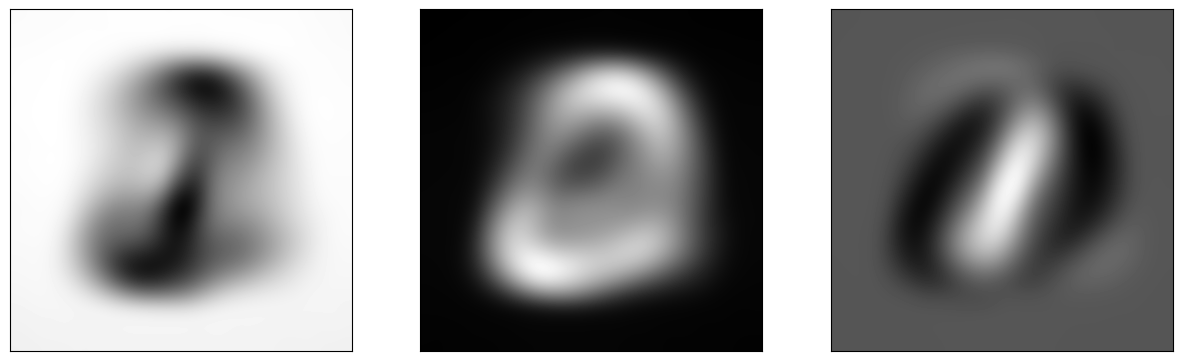

In [ ]:
# pca for stacked data
from sklearn.decomposition import PCA
fig,ax = plt.subplots(1,3, figsize=(15,7))
pca_together_centered=PCA(n_components=3)
pca_together_centered.fit(np.vstack((foreground_0_2.reshape(-1,784),foreground_1_2.reshape(-1,784),background)))
for i in range(3):
    ax[i].imshow(patternimage(pca_together_centered.components_[i,:].reshape(28,28)), cmap="gray", interpolation="bicubic")

for i in range(3):
    ax[i].set_xticks([])
    ax[i].set_yticks([])

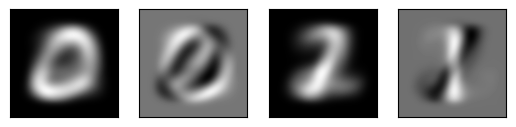

In [ ]:
# pca for each dataset
pattern_list = []

for dataset in [foreground_0_2.reshape(-1,784),foreground_1_2.reshape(-1,784)]:
    pca_top=PCA(n_components=2)
    pca_top.fit_transform(dataset)
    pattern_list.append(pca_top.components_)

fig,ax = plt.subplots(1,4)
for i in range(2):
    for j in range(2):
        ax[2*i+j].imshow(pattern_list[i][j,:].reshape(28,28), cmap="gray", interpolation="bicubic")

for i in range(4):
    ax[i].set_xticks([])
    ax[i].set_yticks([])

    

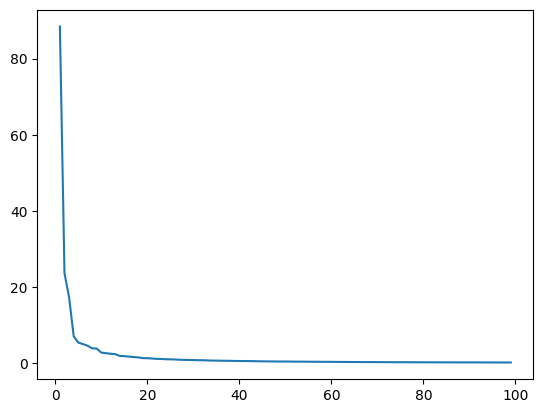

In [29]:
# MCPCA 
df_lists = [background, foreground_0_2, foreground_1_2]
T = mcpca.cov_tensor(df_lists)
# savemat("MNIST/MNIST_cov_tensor.mat",{"T":T})
U,D,Vt = np.linalg.svd(T.reshape(784,-1))
plt.plot(range(1,100),D[:99])

In [ ]:
# from scipy.io import savemat
# savemat("MNIST/MNIST_cov_tensor.mat",{"T":T})

In [ ]:
# takes 38m
best_rank, rank_similarities = mcpca.choose_rank(T,range(5,30),stats = True,cos_sim_threshold=0.8)
np.save("MNIST/rank_similarities.npy", rank_similarities)

In [7]:
def plot_rank_stability_analysis(rank_range, rank_similarities,
                                figsize=(12, 8), show_error_bars=True):
    """
    Plot the rank stability analysis results with error bars and detailed visualization.
    
    Parameters:
    -----------
    rank_range : range or list
        Range of ranks tested
    rank_similarities : dict
        Detailed similarity statistics from compute_rank_stability_analysis
    avg_similarities : list
        Average similarities for each rank
    figsize : tuple
        Figure size
    show_error_bars : bool
        Whether to show error bars (standard deviation)
    """
    ranks = list(rank_range)
    
    # Extract statistics
    means = [rank_similarities[r]['mean'] for r in ranks]
    stds = [rank_similarities[r]['std'] for r in ranks]
    mins = [rank_similarities[r]['min'] for r in ranks]
    maxs = [rank_similarities[r]['max'] for r in ranks]
    
    # Create the plot
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize)
    
    # Main plot with error bars
    if show_error_bars:
        ax1.errorbar(ranks, means, yerr=stds, 
                    marker='o', markersize=8, linewidth=2, capsize=5,
                    label='Mean ± Std Dev', color='blue', alpha=0.8)
    else:
        ax1.plot(ranks, means, marker='o', markersize=8, linewidth=2, 
                label='Mean Similarity', color='blue')
    
    # Add min/max envelope
    ax1.fill_between(ranks, mins, maxs, alpha=0.2, color='blue', 
                    label='Min-Max Range')
    
    ax1.set_xlabel('Tensor Rank', fontsize=14)
    ax1.set_ylabel('Cosine Similarity between A matrices', fontsize=14)
    ax1.set_title('Tensor Decomposition Stability Analysis\n(Higher = More Stable)', 
                 fontsize=16, fontweight='bold')
    ax1.grid(True, alpha=0.3)
    ax1.legend(fontsize=12)
    
    # Add horizontal line at 0.9 (high stability threshold)
    ax1.axhline(y=0.9, color='red', linestyle='--', alpha=0.7, 
               label='High Stability (0.9)')
    ax1.axhline(y=0.8, color='orange', linestyle='--', alpha=0.7,
               label='Moderate Stability (0.8)')
    
    # Set y-axis limits for better visualization
    y_min = max(0.0, min(mins) - 0.05)
    y_max = min(1.0, max(maxs) + 0.05)
    ax1.set_ylim(y_min, y_max)
    
    # Second subplot: Box plot showing distribution for each rank
    box_data = [rank_similarities[r]['similarities'] for r in ranks]
    
    bp = ax2.boxplot(box_data, positions=ranks, widths=0.5, patch_artist=True)
    
    # Color the boxes based on stability
    for i, (patch, mean_val) in enumerate(zip(bp['boxes'], means)):
        if mean_val >= 0.9:
            patch.set_facecolor('lightgreen')
        elif mean_val >= 0.8:
            patch.set_facecolor('lightyellow') 
        else:
            patch.set_facecolor('lightcoral')
    
    ax2.set_xlabel('Tensor Rank', fontsize=14)
    ax2.set_ylabel('Cosine Similarity Distribution', fontsize=14)
    ax2.set_title('Similarity Distribution by Rank\n(Box Plot)', fontsize=14, fontweight='bold')
    ax2.grid(True, alpha=0.3)
    
    # Add stability threshold lines to box plot
    # ax2.axhline(y=0.9, color='red', linestyle='--', alpha=0.7)
    ax2.axhline(y=0.8, color='orange', linestyle='--', alpha=0.7)
    
    plt.tight_layout()
    plt.show()

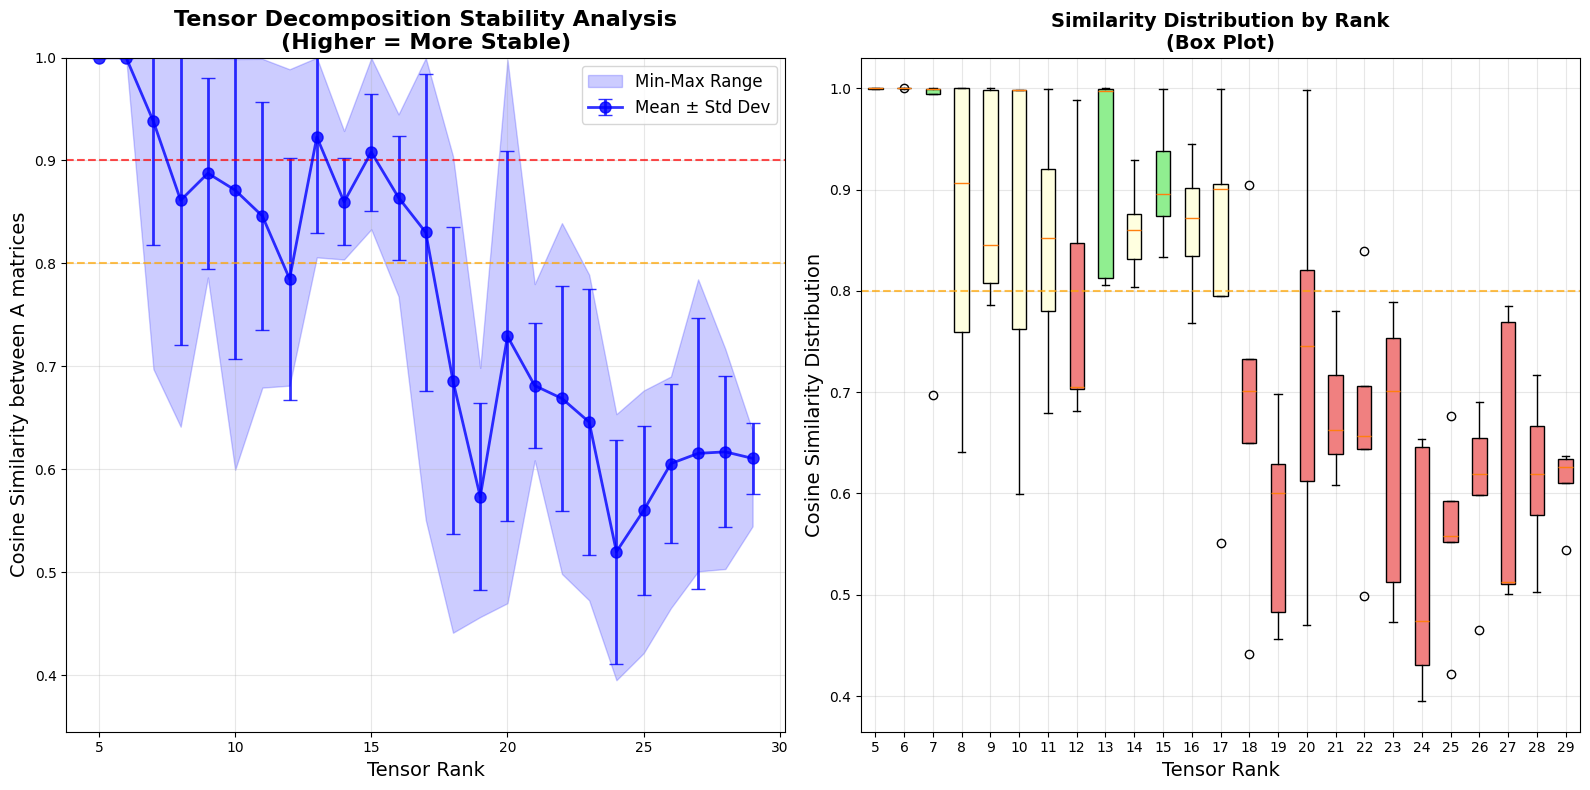

In [8]:
rank_similarities = np.load(
    "rank_similarities.npy",
    allow_pickle=True
).item()


plot_rank_stability_analysis(range(5,30),rank_similarities,figsize=(16,8))

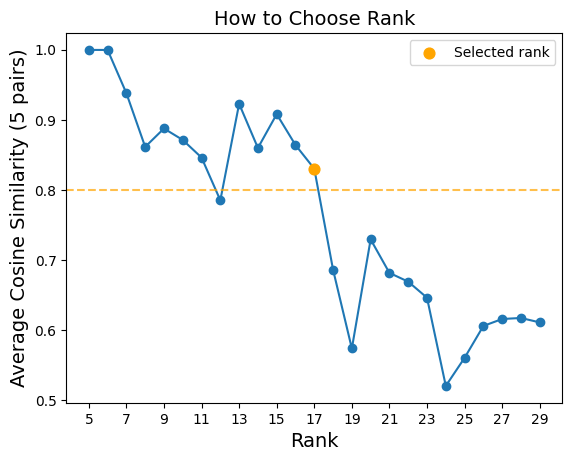

In [9]:
avg_similarities = [k['mean'] for k in rank_similarities.values()]
fig,ax = plt.subplots()
ax.plot(range(5,30),avg_similarities,marker = 'o')
ax.scatter(
    17,
    avg_similarities[12],
    s=60,
    zorder=5,
    color = 'orange',
    label='Selected rank'
)
ax.legend()
ax.set_xlabel('Rank', fontsize=14)
ax.set_ylabel('Average Cosine Similarity (5 pairs)', fontsize=14)
ax.set_title('How to Choose Rank', fontsize=14)
ax.set_xticks(range(5,30,2))
ax.axhline(y=0.8, color='orange', linestyle='--', alpha=0.7,
               label='Moderate Stability (0.8)')


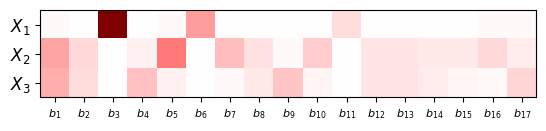

In [ ]:
# MCPCA with r = 17
# 12.1s
np.random.seed(0)
A,B_nnls = mcpca.MCPCA_decompose(T,17,plot_B = True)

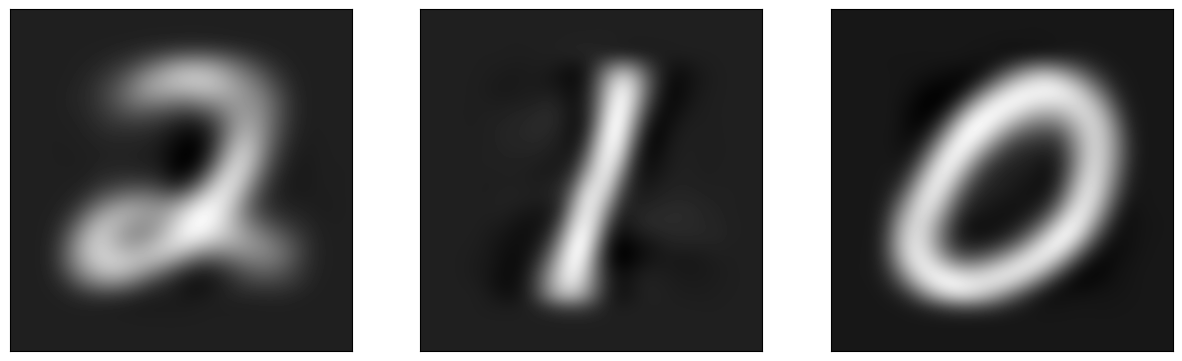

In [ ]:
fig,ax = plt.subplots(1,3, figsize=(15,7))
ax[0].imshow(patternimage(-A[:,0]), cmap="gray", interpolation="bicubic")
ax[1].imshow(patternimage(A[:,3]), cmap="gray", interpolation="bicubic")
ax[2].imshow(patternimage(-A[:,4]), cmap="gray", interpolation="bicubic")
for i in range(3):
    ax[i].set_xticks([])
    ax[i].set_yticks([])

# plot images of other methods

## NLS

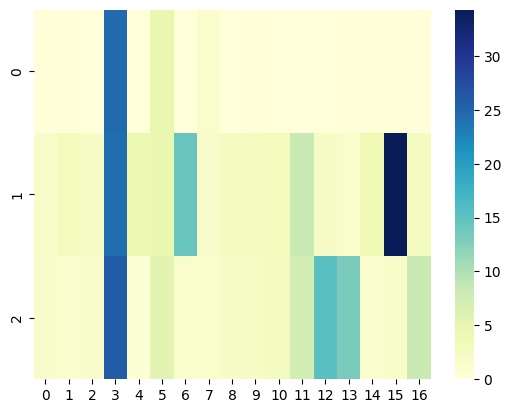

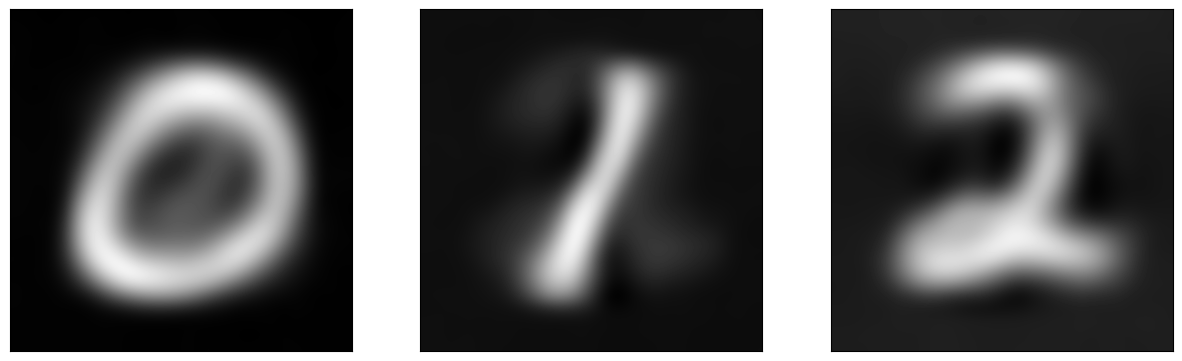

In [ ]:
from scipy.io import loadmat 
data = loadmat("MNIST/NLS.mat")
A= data["A"]
B = data["B"]
sns.heatmap(B, cmap="YlGnBu")
fig,ax = plt.subplots(1,3, figsize=(15,7))
ax[0].imshow(patternimage(-A[:,15]), cmap="gray", interpolation="bicubic")
ax[2].imshow(patternimage(-A[:,11]), cmap="gray", interpolation="bicubic")
ax[1].imshow(patternimage(-A[:,12]), cmap="gray", interpolation="bicubic")
for i in range(3):
    ax[i].set_xticks([])
    ax[i].set_yticks([])

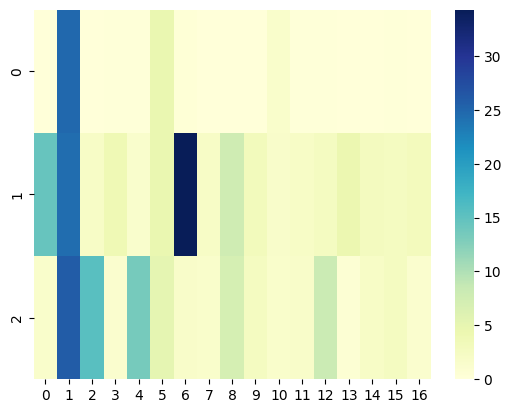

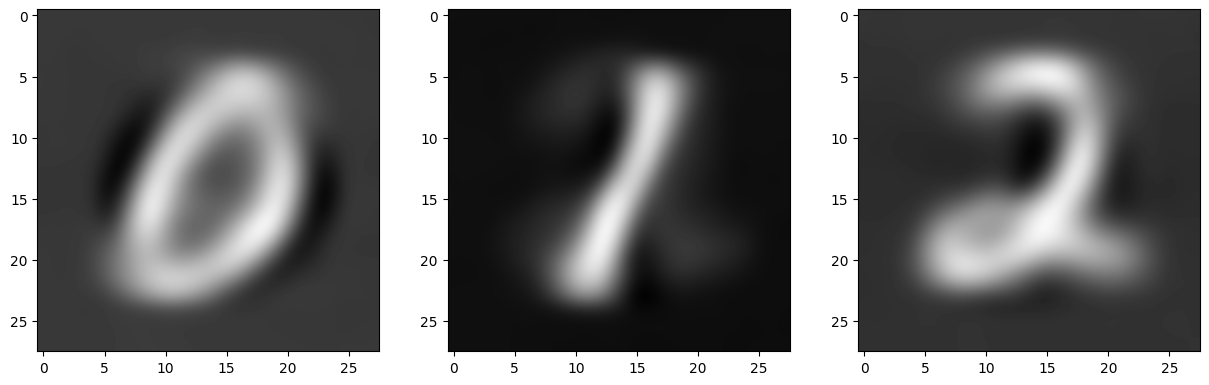

In [ ]:
from scipy.io import loadmat 
data = loadmat("MNIST/NLS_svd_init.mat")
A= data["A"]
B = data["B"]
sns.heatmap(B, cmap="YlGnBu")
fig,ax = plt.subplots(1,3, figsize=(15,7))
ax[0].imshow(patternimage(-A[:,0]), cmap="gray", interpolation="bicubic")
ax[1].imshow(patternimage(-A[:,2]), cmap="gray", interpolation="bicubic")
ax[2].imshow(patternimage(A[:,8]), cmap="gray", interpolation="bicubic")

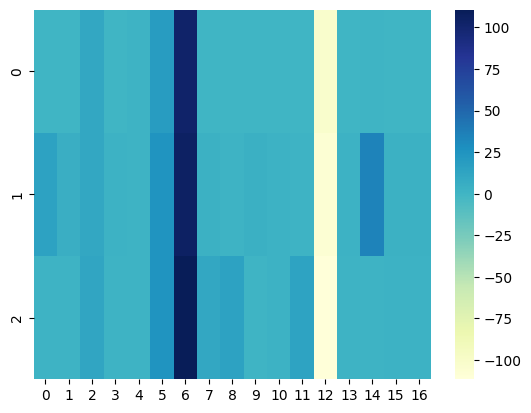

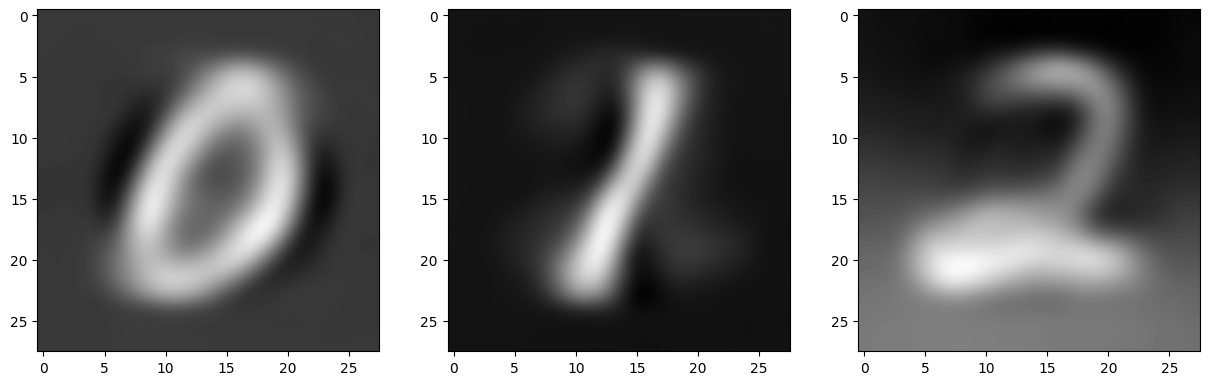

In [ ]:
from scipy.io import loadmat 
data = loadmat("MNIST/NLS_jennrich_init.mat")
A= data["A"]
B = data["B"]
sns.heatmap(B, cmap="YlGnBu")
fig,ax = plt.subplots(1,3, figsize=(15,7))
ax[0].imshow(patternimage(A[:,0]), cmap="gray", interpolation="bicubic")
ax[2].imshow(patternimage(A[:,2]), cmap="gray", interpolation="bicubic")
ax[1].imshow(patternimage(A[:,8]), cmap="gray", interpolation="bicubic")

## FFDIAG

In [ ]:
from scipy.io import loadmat 
data = loadmat("MNIST/FFDIAG.mat")
A= data["A"]
invA = np.linalg.inv(A)
B = []
for i in range(3):
    cov = T[:,:,i]
    B.append(np.diag(invA.T @ cov @ invA))

array([0.01757849, 0.02025193, 0.02395672, 0.02536102, 0.02984067,
       0.03103442, 0.03338235, 0.0339199 , 0.03561642, 0.03588788])

array([0.24871745, 0.31139096, 0.28133216, 0.42535955, 0.39320172,
       0.3664323 , 0.36973163, 0.30718961, 0.45516187, 1.31655713])

array([0.15308849, 0.1934629 , 0.22585954, 0.30012982, 0.17604243,
       0.24446085, 0.2874767 , 0.257443  , 0.38243385, 0.57427146])

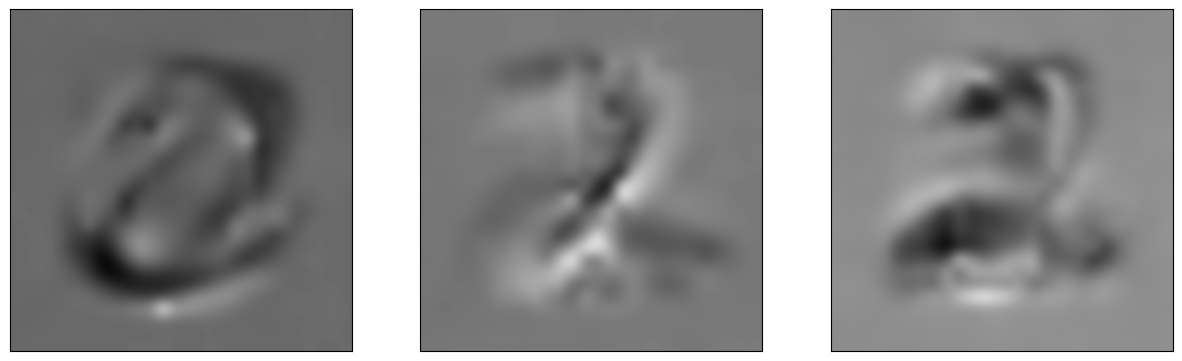

In [ ]:
indices = np.argsort(B[0])[:10]
display(B[0][indices],B[1][indices], B[2][indices])
fig,ax = plt.subplots(1,3, figsize=(15,7))
ax[0].imshow(patternimage(A[:,indices[0]]), cmap="gray", interpolation="bicubic")
ax[2].imshow(patternimage(A[:,indices[9]]), cmap="gray", interpolation="bicubic")
ax[1].imshow(patternimage(A[:,indices[2]]), cmap="gray", interpolation="bicubic")
for i in range(3):
    ax[i].set_xticks([])
    ax[i].set_yticks([])

## QRJ1D

In [ ]:
from scipy.io import loadmat 
data = loadmat("MNIST/QRJ1D.mat")
A= data["A"]
invA = np.linalg.inv(A)
B = []
for i in range(3):
    cov = T[:,:,i]
    B.append(np.diag(invA.T @ cov @ invA))

array([0.09512769, 0.09568821, 0.09751336, 0.10994622, 0.11056637,
       0.11122852, 0.11134915, 0.11206529, 0.1124606 , 0.11439619])

array([1.21005404, 1.13732237, 0.91559373, 0.61519546, 1.33642478,
       0.96766723, 0.91737822, 1.12530375, 2.24643802, 1.2393291 ])

array([0.85740325, 0.65705833, 1.1448917 , 0.50715071, 0.63637659,
       0.80882778, 0.71428349, 0.88988503, 1.37265295, 0.65513362])

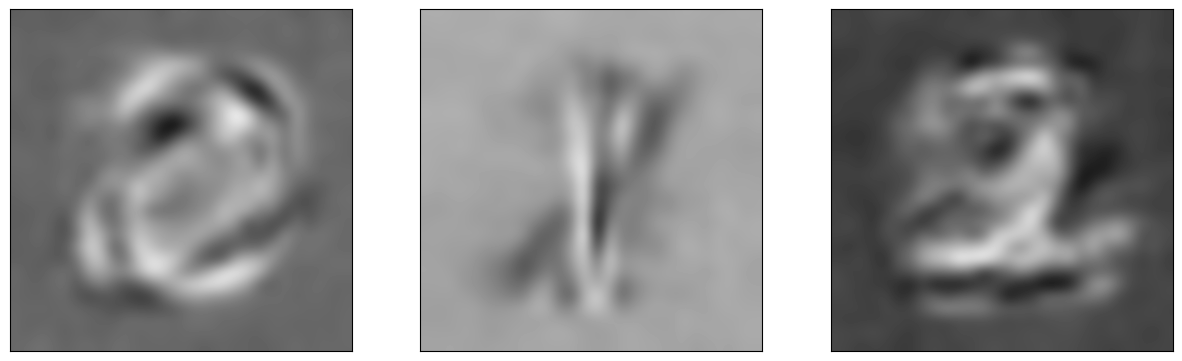

In [ ]:
indices = np.argsort(B[0])[:10]
display(B[0][indices],B[1][indices], B[2][indices])
fig,ax = plt.subplots(1,3, figsize=(15,7))
ax[0].imshow(patternimage(A[:,indices[0]]), cmap="gray", interpolation="bicubic")
ax[2].imshow(patternimage(A[:,indices[2]]), cmap="gray", interpolation="bicubic")
ax[1].imshow(patternimage(A[:,indices[1]]), cmap="gray", interpolation="bicubic")
for i in range(3):
    ax[i].set_xticks([])
    ax[i].set_yticks([])

## JENNRICH

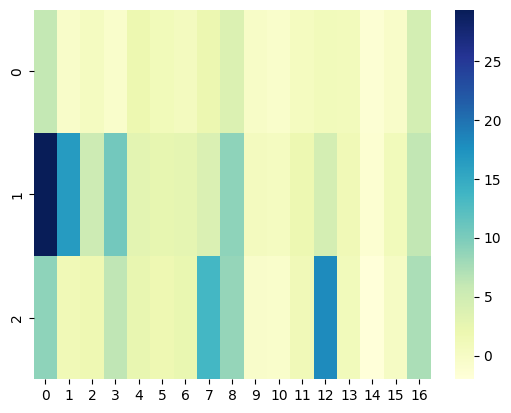

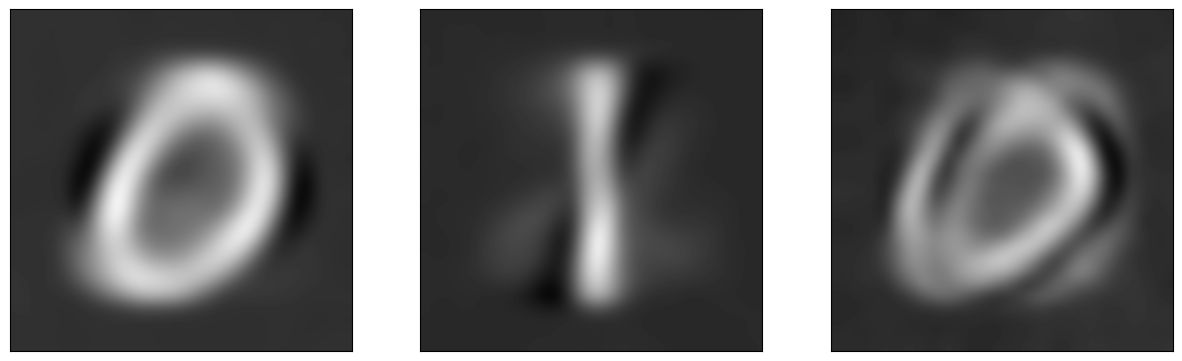

In [ ]:
from scipy.io import loadmat 
data = loadmat("MNIST/Jennrich.mat")
A= data["A"]
B = data["B"]
sns.heatmap(B, cmap="YlGnBu")
fig,ax = plt.subplots(1,3, figsize=(15,7))
ax[0].imshow(patternimage(-A[:,1]), cmap="gray", interpolation="bicubic")
ax[1].imshow(patternimage(A[:,7]), cmap="gray", interpolation="bicubic")
ax[2].imshow(patternimage(-A[:,8]), cmap="gray", interpolation="bicubic")
for i in range(3):
    ax[i].set_xticks([])
    ax[i].set_yticks([])

## MINF

<Axes: >

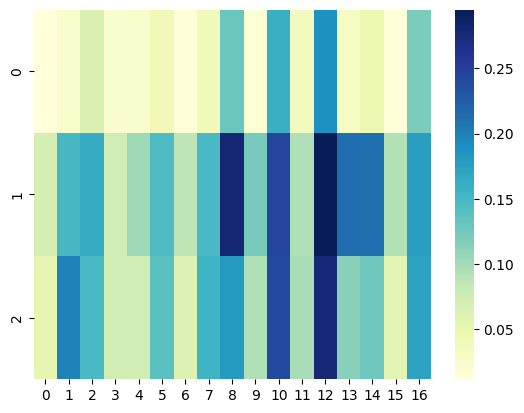

In [ ]:
from scipy.io import loadmat 
data = loadmat("MNIST/MINF.mat")
A= data["A"]
A = A/np.linalg.norm(A,axis = 1, keepdims=True)
B = data["B"]
sns.heatmap(B,cmap="YlGnBu")

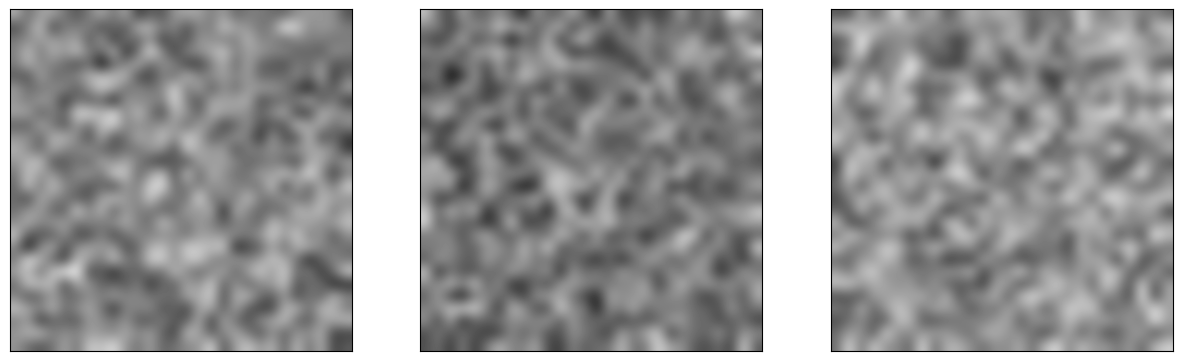

In [ ]:
fig,ax = plt.subplots(1,3, figsize=(15,7))
ax[0].imshow(patternimage(A[:,1]), cmap="gray", interpolation="bicubic")
ax[1].imshow(patternimage(A[:,8]), cmap="gray", interpolation="bicubic")
ax[2].imshow(patternimage(A[:,12]), cmap="gray", interpolation="bicubic")
for i in range(3):
    ax[i].set_xticks([])
    ax[i].set_yticks([])

## ALS

<Axes: >

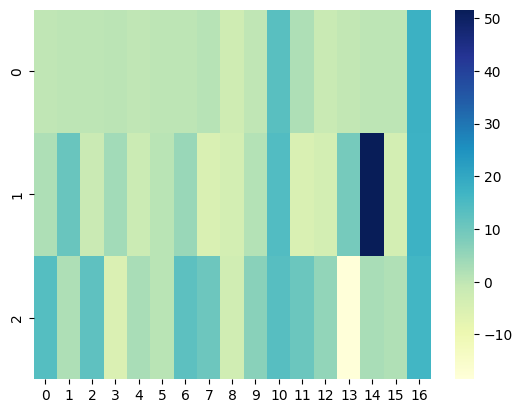

In [ ]:
from scipy.io import loadmat 
data = loadmat("MNIST/ALS.mat")
A= data["A"]
A = A/np.linalg.norm(A, axis = 1, keepdims = True)
B = data["B"]
sns.heatmap(B,cmap="YlGnBu")

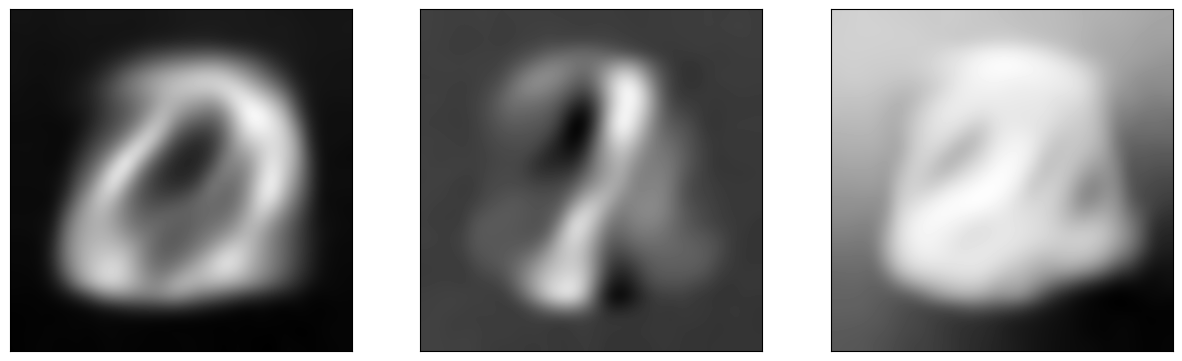

In [ ]:
fig,ax = plt.subplots(1,3, figsize=(15,7))
ax[0].imshow(patternimage(A[:,14]), cmap="gray", interpolation="bicubic")
ax[1].imshow(patternimage(-A[:,0]), cmap="gray", interpolation="bicubic")
ax[2].imshow(patternimage(-A[:,10]), cmap="gray", interpolation="bicubic")
for i in range(3):
    ax[i].set_xticks([])
    ax[i].set_yticks([])

## HOGSVD

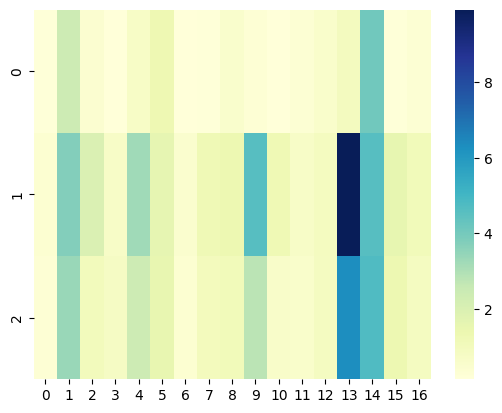

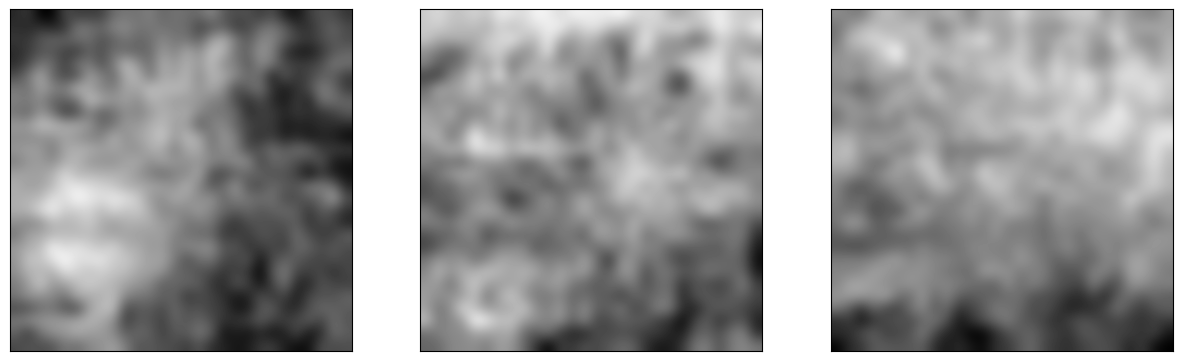

In [ ]:
from scipy.io import loadmat 
data = loadmat("MNIST/HOGSVD.mat")
A= data["A"]
A = A/np.linalg.norm(A, axis = 1, keepdims = True)
B = data["B"]
sns.heatmap(B,cmap="YlGnBu")

fig,ax = plt.subplots(1,3, figsize=(15,7))
ax[0].imshow(patternimage(A[:,9]), cmap="gray", interpolation="bicubic")
ax[1].imshow(patternimage(A[:,14]), cmap="gray", interpolation="bicubic")
ax[2].imshow(patternimage(A[:,1]), cmap="gray", interpolation="bicubic")
for i in range(3):
    ax[i].set_xticks([])
    ax[i].set_yticks([])

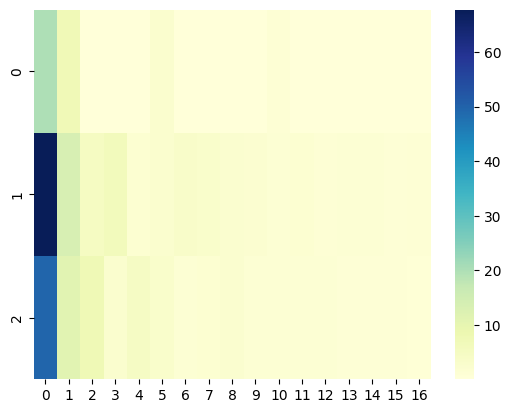

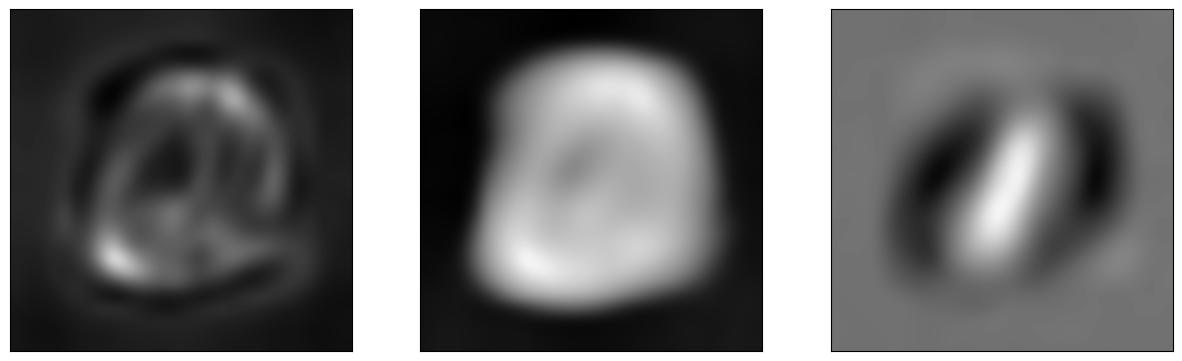

In [ ]:
from scipy.io import loadmat 
data = loadmat("MNIST/SVD.mat")
A= data["A"]
A = A/np.linalg.norm(A, axis = 1, keepdims = True)
B = data["B"]
sns.heatmap(B,cmap="YlGnBu")

fig,ax = plt.subplots(1,3, figsize=(15,7))
ax[0].imshow(patternimage(-A[:,0]), cmap="gray", interpolation="bicubic")
ax[1].imshow(patternimage(-A[:,1]), cmap="gray", interpolation="bicubic")
ax[2].imshow(patternimage(-A[:,2]), cmap="gray", interpolation="bicubic")
for i in range(3):
    ax[i].set_xticks([])
    ax[i].set_yticks([])

# PCA-C & PCA-SVD

In [ ]:
from sklearn.decomposition import PCA
background = np.load("MNIST/background.npy")
foreground_0_2 = np.load("MNIST/foreground_0_2.npy")
foreground_1_2 = np.load("MNIST/foreground_1_2.npy")

n_comps = [14,16,16]
datasets = [background, foreground_0_2, foreground_1_2]
pca_comps = []

for i in range(3):
    pca = PCA(n_components=n_comps[i]).fit(datasets[i])
    pca_comps.append(pca.components_.T)

In [ ]:
M = np.hstack(pca_comps)
U,D,Vt = np.linalg.svd(M)

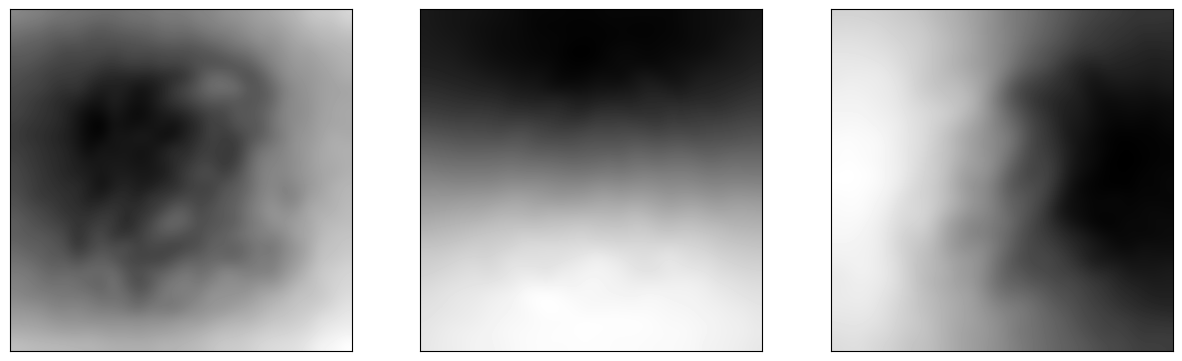

In [ ]:
fig,ax = plt.subplots(1,3, figsize=(15,7))
ax[0].imshow(patternimage(U[:,0]), cmap="gray", interpolation="bicubic")
ax[1].imshow(patternimage(U[:,1]), cmap="gray", interpolation="bicubic")
ax[2].imshow(patternimage(U[:,2]), cmap="gray", interpolation="bicubic")
for i in range(3):
    ax[i].set_xticks([])
    ax[i].set_yticks([])

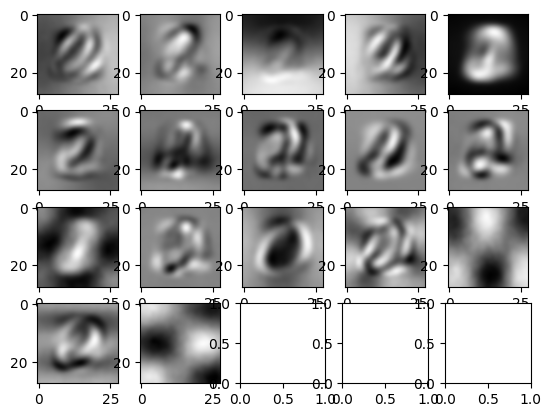

In [ ]:
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters = 17,random_state = 0).fit(M.T)
A = kmeans.cluster_centers_.T

fig, ax = plt.subplots(4,5)
for i in range(20):
    if i<=16:
        ax[i//5][i%5].imshow(patternimage(A[:,i]), cmap="gray", interpolation="bicubic")

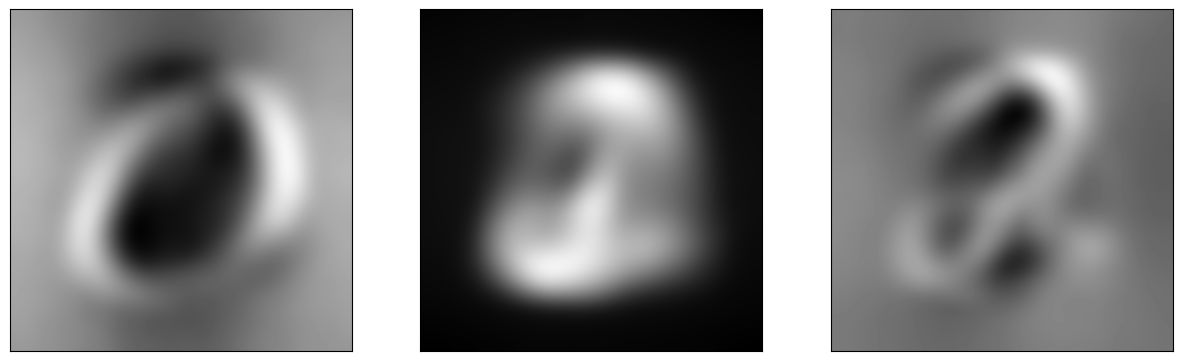

In [ ]:
fig,ax = plt.subplots(1,3, figsize=(15,7))
ax[1].imshow(patternimage(A[:,4]), cmap="gray", interpolation="bicubic")
ax[0].imshow(patternimage(A[:,12]), cmap="gray", interpolation="bicubic")
ax[2].imshow(patternimage(-A[:,1]), cmap="gray", interpolation="bicubic")
for i in range(3):
    ax[i].set_xticks([])
    ax[i].set_yticks([])